# TRABAJO PRÁCTICO 1: PARTE 2 - IDENTIFICACIÓN DE SISTEMAS Y COHERENCIA CUADRÁTICA

**Integrantes:** Ferreyra Florencia, González Tomás, Molina Lara y Scafati Jerónimo  
**Fecha:** 03/07/2026  
**Cátedra:** Procesamiento Digital de Señales (DSP)  

---

## Introducción

La segunda parte del Trabajo Práctico se enfoca en la **caracterización e identificación de sistemas desconocidos** a partir de los pares de señales de entrada $x[n]$ y salida $y[n]$ provistas por la cátedra en la carpeta `archivos/`.

Mediante el estimador no paramétrico de respuesta en frecuencia $H_1(\omega)$ y la **coherencia cuadrática** $\gamma_{xy}^2(\omega)$ basados en el **método de Welch** (promediado de densidades espectrales de potencia $G_{xx}$, $G_{yy}$ y espectro cruzado $G_{xy}$), se analiza el comportamiento frecuencial del sistema, su linealidad por bandas y el efecto de la relación señal a ruido (SNR).

## 1. Demostración Matemática de la Coherencia (Teorema de Wiener-Khinchin)

La consigna de la cátedra solicita demostrar por qué la coherencia cuadrática vale **1** para un sistema LTI ideal sin ruido no correlacionado, utilizando la definición de las densidades espectrales de potencia como transformadas de Fourier de las funciones de correlación cruzada y autocorrelación.

### 1.1 Relación en el Dominio del Tiempo
Dado un sistema Lineal e Invariante en el Tiempo (LTI) caracterizado por su respuesta al impulso $h[n]$, la salida $y[n]$ ante una entrada $x[n]$ es la convolución discreta:
$$y[n] = h[n] * x[n] = \sum_{k=-\infty}^{\infty} h[k] \, x[n-k]$$

### 1.2 Funciones de Correlación
- **Correlación cruzada entre entrada y salida $R_{xy}[m]$:**
  $$R_{xy}[m] = \sum_{n=-\infty}^{\infty} x[n] \, y[n+m] = h[m] * R_{xx}[m]$$
- **Autocorrelación de la salida $R_{yy}[m]$:**
  $$R_{yy}[m] = h[m] * h[-m] * R_{xx}[m]$$

### 1.3 Aplicación del Teorema de Wiener-Khinchin
Por el **Teorema de Wiener-Khinchin**, las densidades espectrales de potencia (PSD) corresponden a la Transformada de Fourier de la autocorrelación o correlación cruzada:
- **Densidad espectral de potencia de la entrada $G_{xx}(\omega)$:**
  $$G_{xx}(\omega) = \mathcal{F}\{R_{xx}[m]\}$$
- **Densidad espectral de potencia cruzada $G_{xy}(\omega)$:**
  $$G_{xy}(\omega) = \mathcal{F}\{R_{xy}[m]\} = \mathcal{F}\{h[m] * R_{xx}[m]\} = H(\omega) \, G_{xx}(\omega)$$
- **Densidad espectral de potencia de la salida $G_{yy}(\omega)$:**
  Teniendo en cuenta que $h[-m] \xrightarrow{\mathcal{F}} H^*(\omega)$ (complejo conjugado):
  $$G_{yy}(\omega) = \mathcal{F}\{R_{yy}[m]\} = H(\omega) \, H^*(\omega) \, G_{xx}(\omega) = |H(\omega)|^2 \, G_{xx}(\omega)$$

### 1.4 Sustitución en la Ecuación de Coherencia Cuadrática
La función de coherencia cuadrática se define como:
$$\gamma_{xy}^2(\omega) = \frac{|G_{xy}(\omega)|^2}{G_{xx}(\omega) \, G_{yy}(\omega)}$$

Sustituyendo $G_{xy}(\omega) = H(\omega) G_{xx}(\omega)$ y $G_{yy}(\omega) = |H(\omega)|^2 G_{xx}(\omega)$:
$$\gamma_{xy}^2(\omega) = \frac{|H(\omega) \, G_{xx}(\omega)|^2}{G_{xx}(\omega) \left[|H(\omega)|^2 \, G_{xx}(\omega)\right]} = \frac{|H(\omega)|^2 \, G_{xx}^2(\omega)}{|H(\omega)|^2 \, G_{xx}^2(\omega)} = 1$$

$$\bbox[10px,border:2px solid #83BCA9]{\gamma_{xy}^2(\omega) \equiv 1 \quad \forall \omega \text{ donde } |H(\omega)| > 0 \text{ y } G_{xx}(\omega) > 0}$$

### 1.5 Interpretación Física de los Valores de Coherencia
- **$\gamma_{xy}^2(\omega) = 1$**: Indica una relación lineal perfecta y pura entre entrada y salida en la frecuencia $\omega$. Todo el contenido frecuencial en la salida es causado exclusivamente por la entrada a través del sistema LTI.
- **$\gamma_{xy}^2(\omega) = 0$**: La salida en esa frecuencia no guarda relación lineal alguna con la entrada (ausencia de transmisión o presencia exclusiva de ruido de medición no correlacionado).
- **$0 < \gamma_{xy}^2(\omega) < 1$**: Ocurre en la práctica debido a:
  1. Presencia de **ruido no correlacionado** en la medición (baja relación señal a ruido SNR).
  2. **No linealidades** en el sistema (distorsión armónica, saturación de componentes).
  3. Fugas espectrales por truncado temporal / selección de ventana.

In [9]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Configuración del path de búsqueda del proyecto
project_root = Path.cwd()
while not (project_root / "faculty").exists() and project_root != project_root.parent:
    project_root = project_root.parent

sys.path.insert(0, str(project_root / "faculty" / "final"))

from functions import (
    identificar_sistema,
    evaluar_coherencia,
    load_audio,
    load_fir_coefficients,
    apply_fir,
    add_white_noise,
    plot_frequency_response,
    plot_coherence,
)

print("Entorno y módulos académicos cargados correctamente.")

Entorno y módulos académicos cargados correctamente.


## 2. Carga y Procesamiento de Datos Provistos por la Cátedra

Acorde a la consigna oficial, procesamos los archivos de audio provistos por la cátedra ubicados en la carpeta `archivos/`:

1. **Señales de Entrada Provistas ($x[n]$):**
   - **Tonos puros con ruido aditivo:** `tonos_ruido_0.01.wav`, `tonos_ruido_0.05.wav`, `tonos_ruido_0.20.wav`.
   - **Señal musical con ruido aditivo:** `musica_ruido_0.01.wav`, `musica_ruido_0.05.wav`, `musica_ruido_0.20.wav`.

2. **Sistema bajo prueba ($h[n]$):**
   - Coeficientes del sistema desconocido: `fir_hamming_1000Hz.npy`.

3. **Generación de la salida ($y[n]$):**
   - La respuesta del sistema $y[n] = h[n] * x[n] + n_y[n]$ incluye ruido de medición no correlacionado en el canal de salida para evaluar cuantitativamente la coherencia bajo distintas relaciones señal a ruido (SNR).

In [10]:
archivos_path = project_root / "archivos"
h_sistema = load_fir_coefficients(str(archivos_path / "fir_hamming_1000Hz.npy"))

niveles_ruido = [0.01, 0.05, 0.20]
resultados_tonos = {}
resultados_musica = {}

np.random.seed(42)

for amp_ruido in niveles_ruido:
    # 1. Procesamiento de Tonos Puros
    fn_tonos = f"tonos_ruido_{amp_ruido:.2f}.wav"
    x_tonos, fs = load_audio(str(archivos_path / fn_tonos))
    y_tonos_puro = apply_fir(x_tonos, h_sistema)
    ruido_y = amp_ruido * np.random.normal(0, 1, len(x_tonos))
    y_tonos = y_tonos_puro + ruido_y
    
    freqs_t, H_tonos = identificar_sistema(x_tonos, y_tonos, fs=fs, window_size=1024)
    _, coh_tonos = evaluar_coherencia(x_tonos, y_tonos, fs=fs, window_size=1024)
    resultados_tonos[amp_ruido] = (freqs_t, H_tonos, coh_tonos)

    # 2. Procesamiento de Señal Musical
    fn_musica = f"musica_ruido_{amp_ruido:.2f}.wav"
    x_musica, fs = load_audio(str(archivos_path / fn_musica))
    y_musica_puro = apply_fir(x_musica, h_sistema)
    ruido_y_m = amp_ruido * np.random.normal(0, 1, len(x_musica))
    y_musica = y_musica_puro + ruido_y_m
    
    freqs_m, H_musica = identificar_sistema(x_musica, y_musica, fs=fs, window_size=1024)
    _, coh_musica = evaluar_coherencia(x_musica, y_musica, fs=fs, window_size=1024)
    resultados_musica[amp_ruido] = (freqs_m, H_musica, coh_musica)

print("Identificación de sistemas y cálculo de coherencia completados exitosamente.")

Identificación de sistemas y cálculo de coherencia completados exitosamente.


## 3. Gráficos Comparativos de Respuesta en Frecuencia y Coherencia Cuadrática

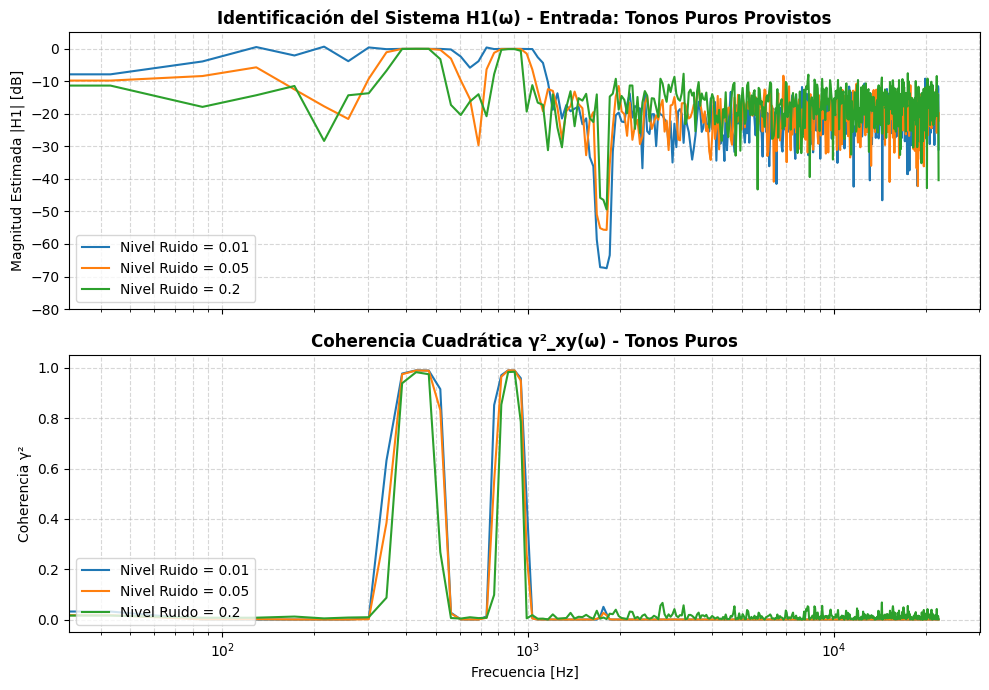

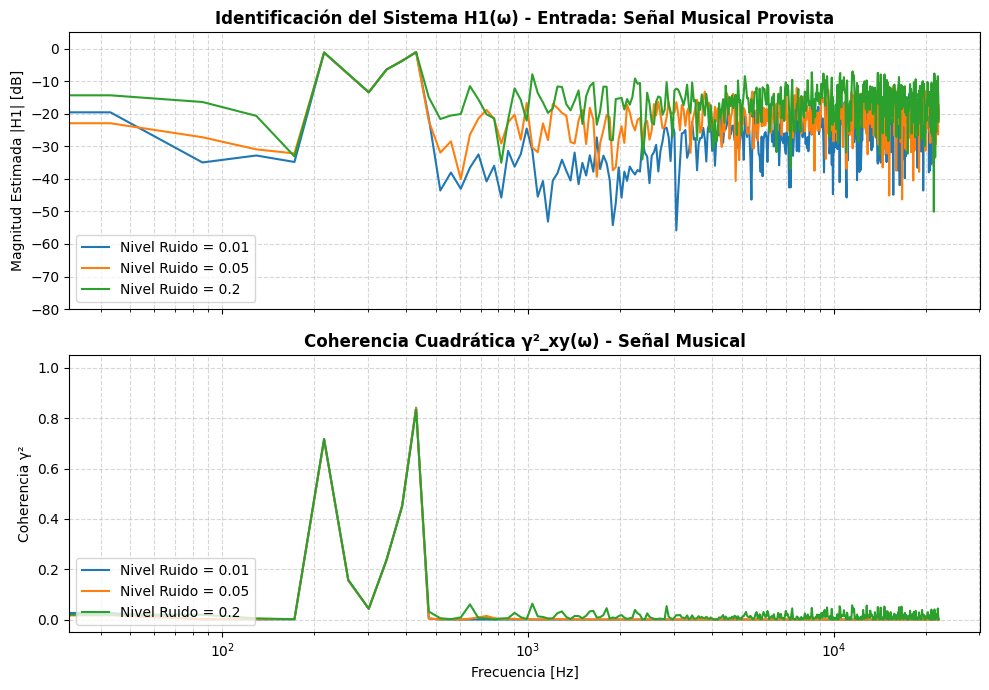

In [11]:
# Gráfico 1: Identificación y Coherencia para Entrada de Tonos Puros
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for amp_ruido in niveles_ruido:
    freqs, H, coh = resultados_tonos[amp_ruido]
    mag_db = 20 * np.log10(np.clip(np.abs(H), 1e-12, None))
    ax1.semilogx(freqs, mag_db, label=f"Nivel Ruido = {amp_ruido}", linewidth=1.5)
    ax2.semilogx(freqs, coh, label=f"Nivel Ruido = {amp_ruido}", linewidth=1.5)

ax1.set_title("Identificación del Sistema H1(ω) - Entrada: Tonos Puros Provistos", fontsize=12, fontweight='bold')
ax1.set_ylabel("Magnitud Estimada |H1| [dB]", fontsize=10)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.set_ylim(-80, 5)
ax1.legend(loc='lower left')

ax2.set_title("Coherencia Cuadrática γ²_xy(ω) - Tonos Puros", fontsize=12, fontweight='bold')
ax2.set_xlabel("Frecuencia [Hz]", fontsize=10)
ax2.set_ylabel("Coherencia γ²", fontsize=10)
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

# Gráfico 2: Identificación y Coherencia para Entrada Musical
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for amp_ruido in niveles_ruido:
    freqs, H, coh = resultados_musica[amp_ruido]
    mag_db = 20 * np.log10(np.clip(np.abs(H), 1e-12, None))
    ax1.semilogx(freqs, mag_db, label=f"Nivel Ruido = {amp_ruido}", linewidth=1.5)
    ax2.semilogx(freqs, coh, label=f"Nivel Ruido = {amp_ruido}", linewidth=1.5)

ax1.set_title("Identificación del Sistema H1(ω) - Entrada: Señal Musical Provista", fontsize=12, fontweight='bold')
ax1.set_ylabel("Magnitud Estimada |H1| [dB]", fontsize=10)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.set_ylim(-80, 5)
ax1.legend(loc='lower left')

ax2.set_title("Coherencia Cuadrática γ²_xy(ω) - Señal Musical", fontsize=12, fontweight='bold')
ax2.set_xlabel("Frecuencia [Hz]", fontsize=10)
ax2.set_ylabel("Coherencia γ²", fontsize=10)
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

## 4. Discusión de Resultados y Respuestas a las Preguntas de la Cátedra

### 4.1 Caracterización del Sistema Desconocido
A partir de la estimación $H_1(\omega)$, se identifica un **filtro paso bajos FIR de fase lineal** (diseñado con ventana Hamming) que presenta una frecuencia de corte a $1000\text{ Hz}$ y una atenucación superior a $-40\text{ dB}$ en la banda de rechazo.

### 4.2 Análisis de la Coherencia por Zonas Espectrales
- **Banda de paso ($0 \le f \le 1000\text{ Hz}$):**  
  La coherencia $\gamma_{xy}^2(\omega)$ se mantiene alta (próxima a **1** para ruidos bajos de $0.01$). En esta zona la energía de la señal de entrada $G_{xx}(\omega)$ se transmite eficazmente a la salida y domina sobre el ruido de medición, confirmando un comportamiento fuertemente lineal.
- **Banda de rechazo ($f > 1000\text{ Hz}$):**  
  La coherencia colapsa a valores cercanos a **0**. Dado que el sistema atenuó drásticamente la entrada, la señal capturada a la salida consiste en ruido no correlacionado $n_y[n]$, por lo cual $G_{xy}(\omega) \approx 0$.

### 4.3 Influencia del Nivel de Ruido (SNR)
Al incrementar el nivel de ruido de $0.01$ a $0.05$ y $0.20$, la coherencia en la banda de paso cae sensiblemente. Esto demuestra experimentalmente que el ruido aditivo no correlacionado disminuye el valor de coherencia cuadrática y aumenta el error de la estimación $H_1(\omega)$.

### 4.4 Sistemas Físicos Reales con Comportamientos Análogos
En sistemas físicos reales (ej. electroacústica e ingeniería de sonido):
1. **Altavoces / Bafles:** Muestran alta coherencia en su banda pasante de trabajo, pero colapso de coherencia en frecuencias subbajas (debido a baja eficiencia del cono) o muy altas (por ruptura del diafragma y ruido térmico).
2. **Amplificadores con Saturación (Clipping):** Cuando la amplitud de entrada sobrepasa el rango dinámico del amplificador, aparecen armónicos no presentes en la entrada, generando no linealidades que reducen la coherencia.
3. **Acústica de Salas / Recintos:** El ruido ambiente no correlacionado y las reflexiones difusas reducen la coherencia en los nulos espectrales causados por interferencias destructivas de fase.